# Proyecto: Estacionalidad de Ventas para Microempresarios de Retail
Dataset: Sample Superstore (Kaggle) — Técnica: Series Temporales — 6 gráficos (3 en 2D, 3 en 3D) con GNU Plot

In [29]:
!apt-get install -y gnuplot

import kagglehub
import pandas as pd
import os
import subprocess
from IPython.display import Image

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
gnuplot is already the newest version (5.4.2+dfsg2-2).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


In [30]:
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")
print("Path to dataset files:", path)
print("Archivos disponibles:", os.listdir(path))

archivo_csv = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, archivo_csv), encoding="latin1")

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["anio_mes"] = df["Order Date"].dt.to_period("M").astype(str)
df["mes_num"] = df["Order Date"].dt.month
df["anio"] = df["Order Date"].dt.year

print("\nVista previa:")
print(df[["Order Date", "Category", "Region", "Sales"]].head())
print("\nCategorías:", df["Category"].unique())
print("Regiones:", df["Region"].unique())
print("Años:", sorted(df["anio"].unique()))

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Path to dataset files: /kaggle/input/superstore-dataset-final
Archivos disponibles: ['Sample - Superstore.csv']

Vista previa:
  Order Date         Category Region     Sales
0 2016-11-08        Furniture  South  261.9600
1 2016-11-08        Furniture  South  731.9400
2 2016-06-12  Office Supplies   West   14.6200
3 2015-10-11        Furniture  South  957.5775
4 2015-10-11  Office Supplies  South   22.3680

Categorías: ['Furniture' 'Office Supplies' 'Technology']
Regiones: ['South' 'West' 'Central' 'East']
Años: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]


In [31]:
cat_map = {cat: i + 1 for i, cat in enumerate(df["Category"].unique())}
df["cat_idx"] = df["Category"].map(cat_map)
region_map = {r: i + 1 for i, r in enumerate(df["Region"].unique())}
df["reg_idx"] = df["Region"].map(region_map)

ventas_mes = df.groupby("anio_mes")["Sales"].sum().reset_index()
ventas_mes["idx"] = range(1, len(ventas_mes) + 1)
ventas_mes["media_movil"] = ventas_mes["Sales"].rolling(window=3, center=True).mean()
ventas_mes[["idx", "Sales", "media_movil"]].fillna(0).to_csv(
    "g1_tendencia_total.dat", sep=" ", index=False, header=False
)

pivot_cat = df.pivot_table(index="anio_mes", columns="Category", values="Sales", aggfunc="sum").reset_index()
pivot_cat = pivot_cat.merge(ventas_mes[["anio_mes", "idx"]], on="anio_mes").sort_values("idx")
cols_cat = ["idx"] + list(df["Category"].unique())
pivot_cat[cols_cat].fillna(0).to_csv("g2_por_categoria.dat", sep=" ", index=False, header=False)

est_mes = df.groupby("mes_num")["Sales"].mean().reset_index()
est_mes.to_csv("g3_estacionalidad_calendario.dat", sep=" ", index=False, header=False)

ventas_cat_mes = df.groupby(["mes_num", "cat_idx"])["Sales"].mean().reset_index()
ventas_cat_mes.to_csv("g4_3d_categoria.dat", sep=" ", index=False, header=False)

ventas_reg_mes = df.groupby(["mes_num", "reg_idx"])["Sales"].mean().reset_index()
ventas_reg_mes.to_csv("g5_3d_region.dat", sep=" ", index=False, header=False)

ventas_anio_mes = df.groupby(["anio", "mes_num"])["Sales"].sum().reset_index()
ventas_anio_mes["anio_idx"] = ventas_anio_mes["anio"] - ventas_anio_mes["anio"].min() + 1
ventas_anio_mes[["anio_idx", "mes_num", "Sales"]].to_csv("g6_3d_anio_mes.dat", sep=" ", index=False, header=False)

print("Mapeo de categorías:", cat_map)
print("Mapeo de regiones:", region_map)
print("Años (anio_idx 1=", ventas_anio_mes['anio'].min(), "):", sorted(df['anio'].unique()))
print("\n6 archivos .dat generados correctamente.")

Mapeo de categorías: {'Furniture': 1, 'Office Supplies': 2, 'Technology': 3}
Mapeo de regiones: {'South': 1, 'West': 2, 'Central': 3, 'East': 4}
Años (anio_idx 1= 2014 ): [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]

6 archivos .dat generados correctamente.


## Gráficos 2D

STDERR: 


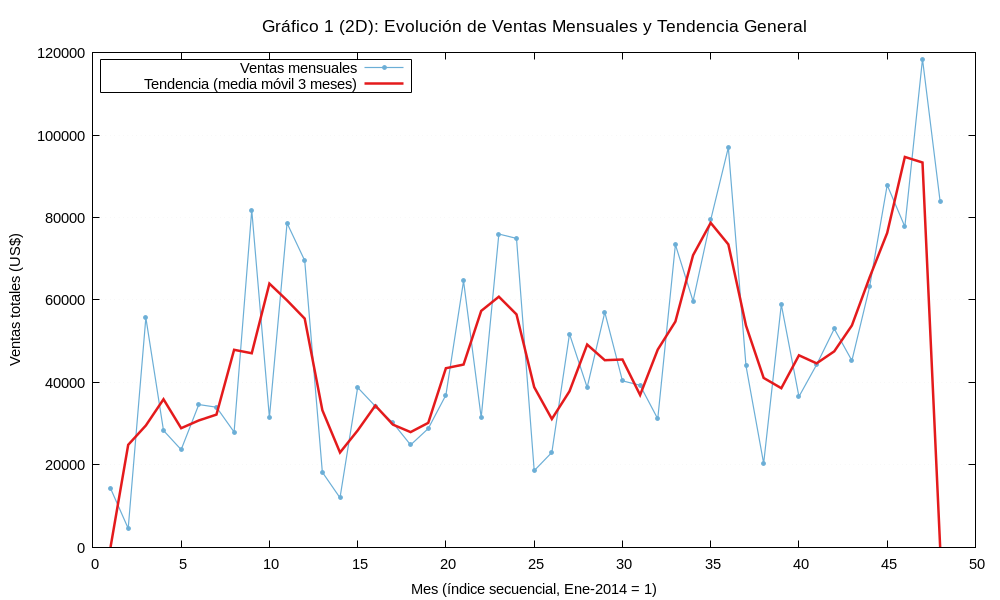

In [32]:
#1) Ventas totales mensuales + tendencia
gnuplot_script_1 = """set terminal pngcairo size 1000,600 font 'Arial,11'
set output 'g1_tendencia_total.png'

set title "Gráfico 1 (2D): Evolución de Ventas Mensuales y Tendencia General" font 'Arial,13'
set xlabel "Mes (índice secuencial, Ene-2014 = 1)"
set ylabel "Ventas totales (US$)"
set grid ytics lc rgb '#dddddd' lw 0.5
set key top left box

set style line 1 lc rgb '#6baed6' lw 1.2 pt 7 ps 0.6
set style line 2 lc rgb '#e41a1c' lw 2.5

plot \"g1_tendencia_total.dat\" using 1:2 with linespoints ls 1 title \"Ventas mensuales\", \\
     \"g1_tendencia_total.dat\" using 1:3 with lines ls 2 title \"Tendencia (media móvil 3 meses)\"

unset output
"""
with open("script_g1.gp", "w", encoding="utf-8") as f:
    f.write(gnuplot_script_1)

r1 = subprocess.run(["gnuplot", "script_g1.gp"], capture_output=True, text=True)
print("STDERR:", r1.stderr)
Image("g1_tendencia_total.png")

STDERR: 


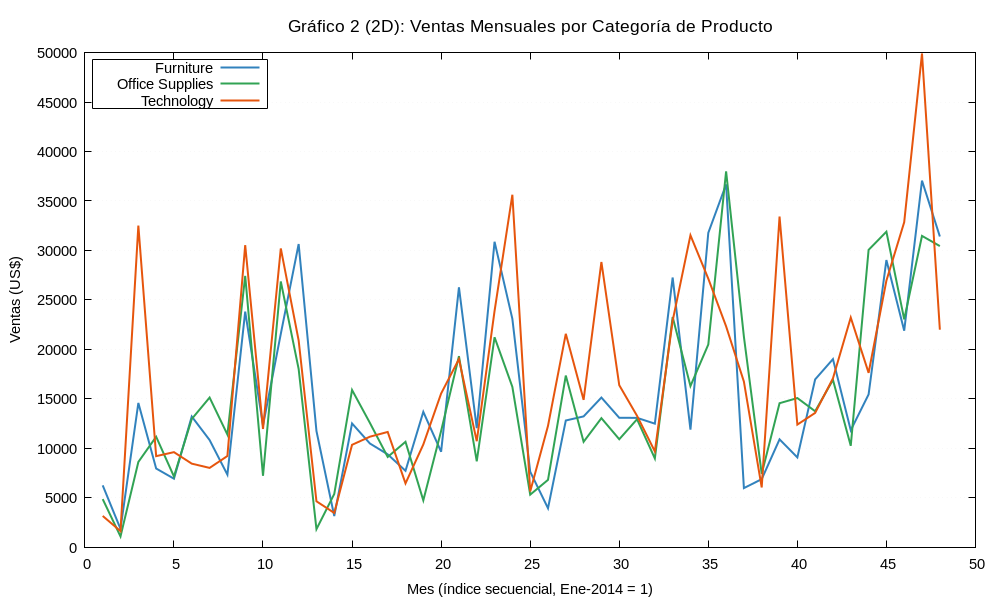

In [33]:
#2) Ventas mensuales por categoría (comparación)
gnuplot_script_2 = """set terminal pngcairo size 1000,600 font 'Arial,11'
set output 'g2_por_categoria.png'

set title "Gráfico 2 (2D): Ventas Mensuales por Categoría de Producto" font 'Arial,13'
set xlabel "Mes (índice secuencial, Ene-2014 = 1)"
set ylabel "Ventas (US$)"
set grid ytics lc rgb '#dddddd' lw 0.5
set key top left box

plot \"g2_por_categoria.dat\" using 1:2 with lines lw 2 lc rgb '#3182bd' title \"Furniture\", \\
     \"g2_por_categoria.dat\" using 1:3 with lines lw 2 lc rgb '#31a354' title \"Office Supplies\", \\
     \"g2_por_categoria.dat\" using 1:4 with lines lw 2 lc rgb '#e6550d' title \"Technology\"

unset output
"""
with open("script_g2.gp", "w", encoding="utf-8") as f:
    f.write(gnuplot_script_2)

r2 = subprocess.run(["gnuplot", "script_g2.gp"], capture_output=True, text=True)
print("STDERR:", r2.stderr)
Image("g2_por_categoria.png")

STDERR: 


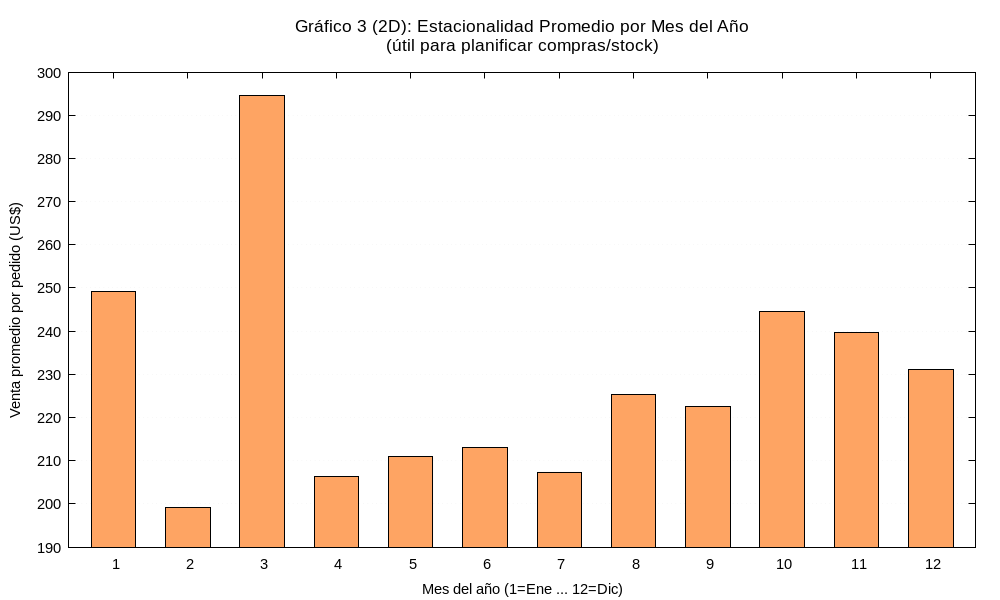

In [34]:
#3) Estacionalidad agregada por mes calendario (barras)
gnuplot_script_3 = """set terminal pngcairo size 1000,600 font 'Arial,11'
set output 'g3_estacionalidad_calendario.png'

set title "Gráfico 3 (2D): Estacionalidad Promedio por Mes del Año\\n(útil para planificar compras/stock)" font 'Arial,13'
set xlabel "Mes del año (1=Ene ... 12=Dic)"
set ylabel "Venta promedio por pedido (US$)"
set xtics 1,1,12
set grid ytics lc rgb '#dddddd' lw 0.5
set style fill solid 0.8 border -1
set boxwidth 0.6

plot \"g3_estacionalidad_calendario.dat\" using 1:2 with boxes lc rgb '#fd8d3c' notitle

unset output
"""
with open("script_g3.gp", "w", encoding="utf-8") as f:
    f.write(gnuplot_script_3)

r3 = subprocess.run(["gnuplot", "script_g3.gp"], capture_output=True, text=True)
print("STDERR:", r3.stderr)
Image("g3_estacionalidad_calendario.png")

## Gráficos 3D

STDERR: 


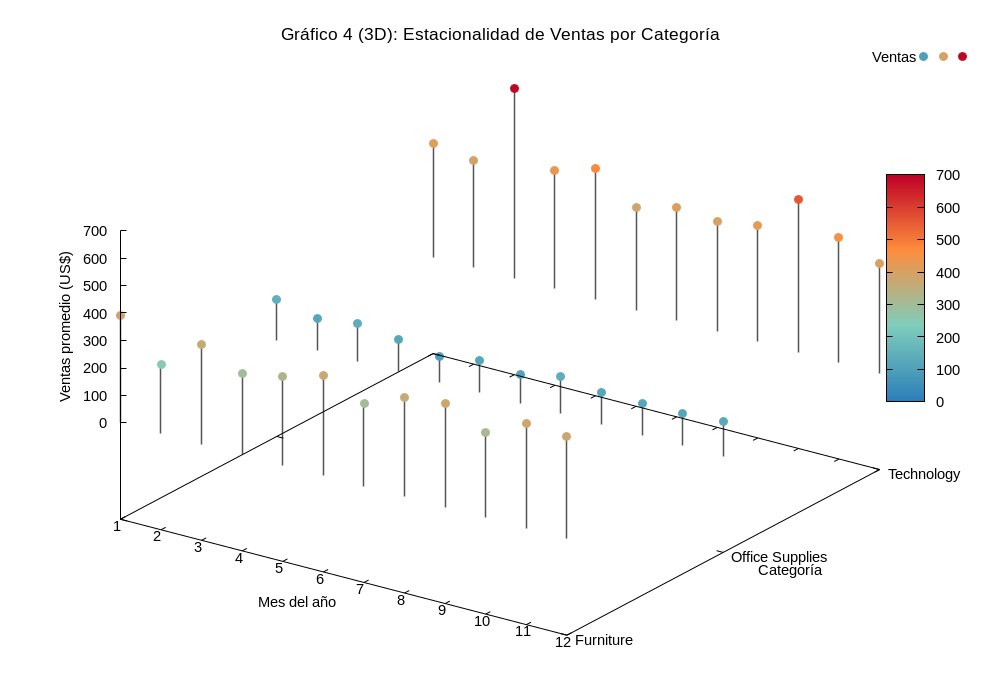

In [35]:
#1 — Mes x Categoría x Ventas promedio
gnuplot_script_4 = """set terminal pngcairo size 1000,700 font 'Arial,11'
set output 'g4_3d_categoria.png'

set title "Gráfico 4 (3D): Estacionalidad de Ventas por Categoría" font 'Arial,13'
set xlabel "Mes del año"
set ylabel "Categoría"
set zlabel "Ventas promedio (US$)" rotate parallel
set ytics (\"Furniture\" 1, \"Office Supplies\" 2, \"Technology\" 3)
set xtics 1,1,12
set view 55, 35
set hidden3d
set pm3d
set palette model RGB defined ( 0 \"#2c7fb8\", 1 \"#7fcdbb\", 2 \"#fd8d3c\", 3 \"#bd0026\" )

splot \"g4_3d_categoria.dat\" using 1:2:3 with impulses lc rgb '#555555' lw 1.5 notitle, \\
      \"g4_3d_categoria.dat\" using 1:2:3:3 with points pt 7 ps 1.3 palette title \"Ventas\"

unset output
"""
with open("script_g4.gp", "w", encoding="utf-8") as f:
    f.write(gnuplot_script_4)

r4 = subprocess.run(["gnuplot", "script_g4.gp"], capture_output=True, text=True)
print("STDERR:", r4.stderr)
Image("g4_3d_categoria.png")

STDERR: 


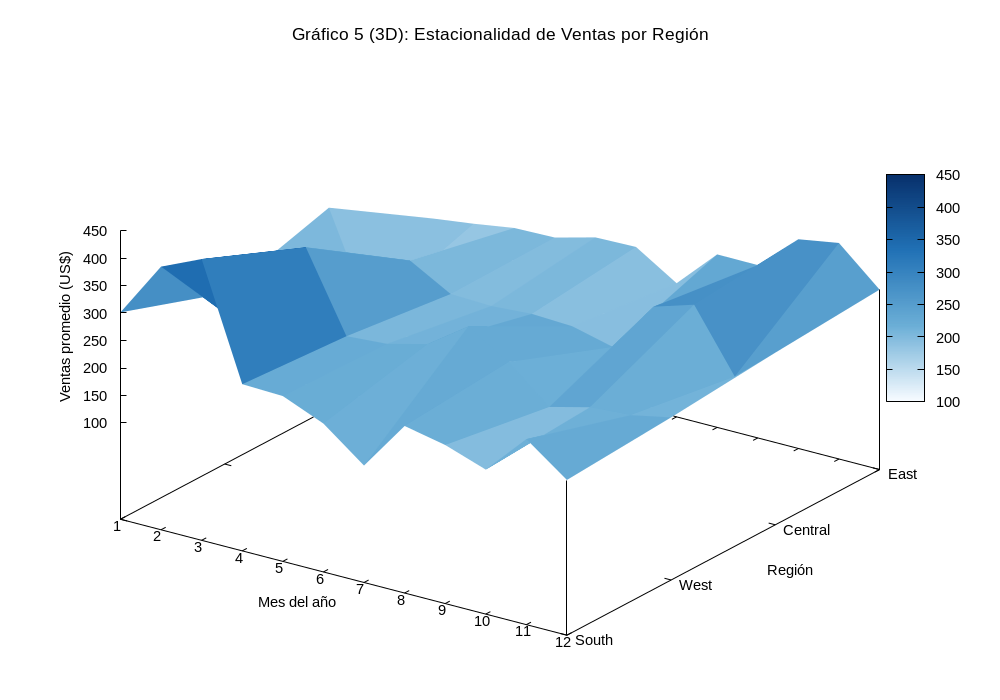

In [36]:
#2 — Mes x Región x Ventas promedio
gnuplot_script_5 = """set terminal pngcairo size 1000,700 font 'Arial,11'
set output 'g5_3d_region.png'

set title "Gráfico 5 (3D): Estacionalidad de Ventas por Región" font 'Arial,13'
set xlabel "Mes del año"
set ylabel "Región"
set zlabel "Ventas promedio (US$)" rotate parallel
set ytics (\"South\" 1, \"West\" 2, \"Central\" 3, \"East\" 4)
set xtics 1,1,12
set view 55, 35
set hidden3d
set dgrid3d 4,12
set pm3d
set palette model RGB defined ( 0 \"#f7fbff\", 1 \"#6baed6\", 2 \"#2171b5\", 3 \"#08306b\" )

splot \"g5_3d_region.dat\" using 1:2:3 with pm3d notitle

unset output
"""
with open("script_g5.gp", "w", encoding="utf-8") as f:
    f.write(gnuplot_script_5)

r5 = subprocess.run(["gnuplot", "script_g5.gp"], capture_output=True, text=True)
print("STDERR:", r5.stderr)
Image("g5_3d_region.png")

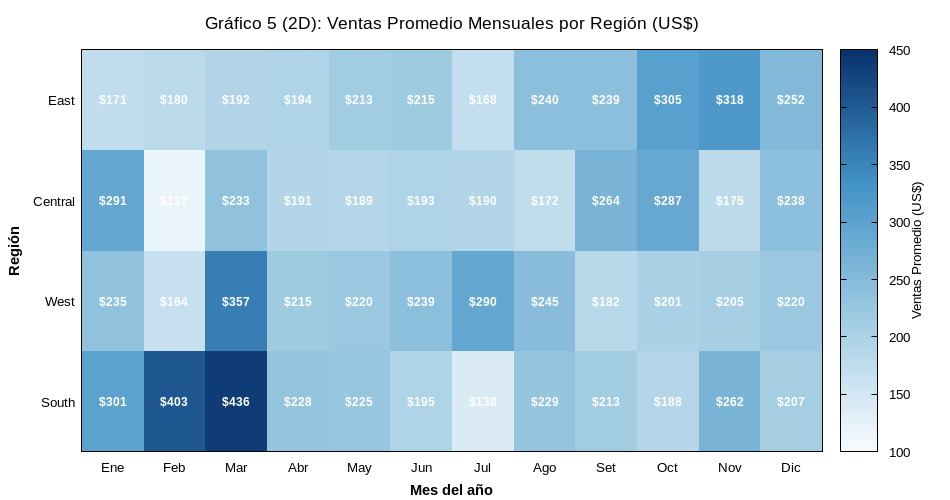

In [40]:
pivot_df = df.pivot_table(
    index="Region", columns="mes_num", values="Sales", aggfunc="mean"
).round(0)  # Redondeamos a enteros para que el texto sea limpio

regions_order = ["South", "West", "Central", "East"]
pivot_df = pivot_df.reindex(index=regions_order, columns=range(1, 13))

# 3. Exportar como lista de coordenadas (X=Mes_Index, Y=Region_Index, Valor)
# Gnuplot necesita índices numéricos desde 0 para alinear las cajas y el texto
data_rows = []
for y_idx, region in enumerate(regions_order):
    for x_idx, month in enumerate(range(1, 13)):
        val = pivot_df.loc[region, month]
        data_rows.append({"x": x_idx, "y": y_idx, "val": val})

flat_df = pd.DataFrame(data_rows)
flat_df.to_csv("heatmap_labels.dat", sep=" ", index=False, header=False)

# 4. Script de Gnuplot (Layer de Imagen + Layer de Texto)
gnuplot_script = """set terminal pngcairo size 950,500 font 'Arial,10'
set output 'g5_heatmap_con_texto.png'

set title "Ventas Promedio Mensuales por Región (US$)" font 'Arial-Bold,13'
set title "Gráfico 5 (2D): Ventas Promedio Mensuales por Región (US$)" font 'Arial,13'
set xlabel "Mes del año" font 'Arial-Bold,11'
set ylabel "Región" font 'Arial-Bold,11'

# Configuración de ejes
set xtics ("Ene" 0, "Feb" 1, "Mar" 2, "Abr" 3, "May" 4, "Jun" 5, "Jul" 6, "Ago" 7, "Set" 8, "Oct" 9, "Nov" 10, "Dic" 11)
set ytics ("South" 0, "West" 1, "Central" 2, "East" 3)

set xrange [-0.5:11.5]
set yrange [-0.5:3.5]

# Paleta de colores
set palette model RGB defined ( 0 "#f7fbff", 1 "#9ecae1", 2 "#4292c6", 3 "#08306b" )
set colorbox
set cblabel "Ventas Promedio (US$)"

# EL TRUCO: Se dibuja el color de fondo y luego se superpone el texto en blanco/negro
# gprintf("%.0f", $3) formatea el número como entero dentro de la celda
plot "heatmap_labels.dat" using 1:2:3 with image notitle, \\
     "heatmap_labels.dat" using 1:2:(gprintf("$%.0f", $3)) with labels font "Arial-Bold,9" tc rgb "#ffffff" notitle

unset output
"""

with open("script_heatmap_labels.gp", "w", encoding="utf-8") as f:
    f.write(gnuplot_script)

# 5. Ejecutar Gnuplot
r = subprocess.run(
    ["gnuplot", "script_heatmap_labels.gp"], capture_output=True, text=True
)

if r.stderr:
    print("Avisos/Errores de Gnuplot:", r.stderr)

Image("g5_heatmap_con_texto.png")

STDERR: 


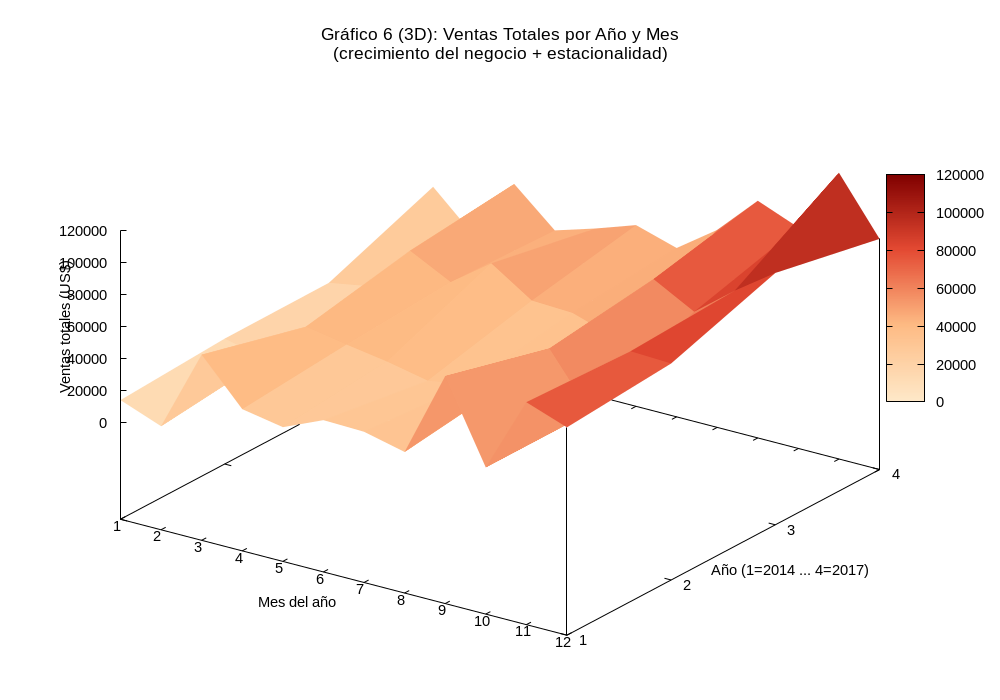

In [38]:
#3 — Año x Mes x Ventas totales (crecimiento + estacionalidad)
gnuplot_script_6 = """set terminal pngcairo size 1000,700 font 'Arial,11'
set output 'g6_3d_anio_mes.png'

set title "Gráfico 6 (3D): Ventas Totales por Año y Mes\\n(crecimiento del negocio + estacionalidad)" font 'Arial,13'
set xlabel "Mes del año"
set ylabel "Año (1=2014 ... 4=2017)"
set zlabel "Ventas totales (US$)" rotate parallel
set xtics 1,1,12
set ytics 1,1,4
set view 55, 35
set hidden3d
set dgrid3d 4,12
set pm3d
set palette model RGB defined ( 0 \"#fee8c8\", 1 \"#fdbb84\", 2 \"#e34a33\", 3 \"#7f0000\" )

splot \"g6_3d_anio_mes.dat\" using 2:1:3 with pm3d notitle

unset output
"""
with open("script_g6.gp", "w", encoding="utf-8") as f:
    f.write(gnuplot_script_6)

r6 = subprocess.run(["gnuplot", "script_g6.gp"], capture_output=True, text=True)
print("STDERR:", r6.stderr)
Image("g6_3d_anio_mes.png")

In [39]:
#Verificación final de los 6 gráficos + insights para la presentación
print("Verificación de los 6 gráficos generados:")
archivos = [
    "g1_tendencia_total.png", "g2_por_categoria.png", "g3_estacionalidad_calendario.png",
    "g4_3d_categoria.png", "g5_3d_region.png", "g6_3d_anio_mes.png"
]
for f in archivos:
    existe = os.path.exists(f)
    tamano = os.path.getsize(f) if existe else "N/A"
    print(f"{f} -> existe: {existe}, tamaño: {tamano} bytes")

print("\n--- Insights para Resultados / Conclusiones ---")
print("Top 3 meses (año-mes) con mayor venta total:")
print(ventas_mes.sort_values("Sales", ascending=False).head(3)[["anio_mes", "Sales"]])

print("\nMes del año (calendario) con mayor venta promedio:")
print(est_mes.sort_values("Sales", ascending=False).head(3))

print("\nCategoría con mayor venta promedio:")
print(df.groupby("Category")["Sales"].mean().sort_values(ascending=False))

print("\nRegión con mayor venta promedio:")
print(df.groupby("Region")["Sales"].mean().sort_values(ascending=False))

Verificación de los 6 gráficos generados:
g1_tendencia_total.png -> existe: True, tamaño: 79858 bytes
g2_por_categoria.png -> existe: True, tamaño: 114443 bytes
g3_estacionalidad_calendario.png -> existe: True, tamaño: 30239 bytes
g4_3d_categoria.png -> existe: True, tamaño: 52882 bytes
g5_3d_region.png -> existe: True, tamaño: 66605 bytes
g6_3d_anio_mes.png -> existe: True, tamaño: 66229 bytes

--- Insights para Resultados / Conclusiones ---
Top 3 meses (año-mes) con mayor venta total:
   anio_mes       Sales
46  2017-11  118447.825
35  2016-12   96999.043
44  2017-09   87866.652

Mes del año (calendario) con mayor venta promedio:
   mes_num       Sales
2        3  294.548116
0        1  249.146550
9       10  244.594609

Categoría con mayor venta promedio:
Category
Technology         452.709276
Furniture          349.834887
Office Supplies    119.324101
Name: Sales, dtype: float64

Región con mayor venta promedio:
Region
South      241.803645
East       238.336110
West       226.4932